In [ ]:
!pip install numba opencv-python matplotlib

In [ ]:
import numpy as np
import cv2
import os
import math
from numba import cuda
import matplotlib.pyplot as plt

print("CUDA Available:", cuda.is_available())


CUDA Available: True


In [ ]:
IMG_SIZE = 28

def load_data(path):
    images = []
    labels = []

    for label, folder in enumerate(["mask", "unmask"]):
        folder_path = os.path.join(path, folder)

        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


X, y = load_data("dataset")
print("Total Images:", len(X))
print("Shape:", X.shape)


Total Images: 40
Shape: (40, 28, 28)


In [ ]:
# ---------------- Convolution ----------------
@cuda.jit
def conv2d(input_img, kernel, output):
    x, y = cuda.grid(2)

    if x < IMG_SIZE-2 and y < IMG_SIZE-2:
        s = 0.0
        for i in range(3):
            for j in range(3):
                s += input_img[x+i, y+j] * kernel[i, j]
        output[x, y] = s


# ---------------- ReLU ----------------
@cuda.jit
def relu(data):
    idx = cuda.grid(1)
    if idx < data.size:
        if data.flat[idx] < 0:
            data.flat[idx] = 0


# ---------------- MaxPooling 2x2 ----------------
@cuda.jit
def maxpool(input_img, output):
    x, y = cuda.grid(2)

    if x < output.shape[0] and y < output.shape[1]:
        in_x = x * 2
        in_y = y * 2

        max_val = input_img[in_x, in_y]

        for i in range(2):
            for j in range(2):
                val = input_img[in_x+i, in_y+j]
                if val > max_val:
                    max_val = val

        output[x, y] = max_val


# ---------------- Fully Connected ----------------
@cuda.jit
def fully_connected(input_vec, weights, bias, output):
    cls = cuda.grid(1)

    if cls < 2:
        s = bias[cls]
        for i in range(input_vec.size):
            s += input_vec[i] * weights[cls, i]
        output[cls] = s


# ---------------- Softmax ----------------
@cuda.jit
def softmax(input_vec, output):
    total = 0.0
    for i in range(2):
        total += math.exp(input_vec[i])

    for i in range(2):
        output[i] = math.exp(input_vec[i]) / total


In [ ]:
kernel = np.random.randn(3,3).astype(np.float32)

conv_out_size = IMG_SIZE - 2
pool_size = conv_out_size // 2
fc_input_size = pool_size * pool_size

fc_weights = np.random.randn(2, fc_input_size).astype(np.float32)
fc_bias = np.zeros(2, dtype=np.float32)


In [ ]:
EPOCHS = 5

threads2d = (16,16)
blocks2d = (math.ceil((IMG_SIZE-2)/16),
            math.ceil((IMG_SIZE-2)/16))

for epoch in range(EPOCHS):

    correct = 0

    for i in range(len(X)):

        img = X[i]
        label = y[i]

        # ----------- Conv -----------
        d_input = cuda.to_device(img)
        d_kernel = cuda.to_device(kernel)

        conv_out = np.zeros((IMG_SIZE-2, IMG_SIZE-2), dtype=np.float32)
        d_conv = cuda.to_device(conv_out)

        conv2d[blocks2d, threads2d](d_input, d_kernel, d_conv)

        # ----------- ReLU -----------
        relu[256,256](d_conv)

        # ----------- Pool -----------
        pool_out = np.zeros((pool_size, pool_size), dtype=np.float32)
        d_pool = cuda.to_device(pool_out)

        maxpool[blocks2d, threads2d](d_conv, d_pool)

        flat = d_pool.copy_to_host().flatten()
        d_flat = cuda.to_device(flat)

        # ----------- FC -----------
        d_weights = cuda.to_device(fc_weights)
        d_bias = cuda.to_device(fc_bias)

        fc_out = np.zeros(2, dtype=np.float32)
        d_fc_out = cuda.to_device(fc_out)

        fully_connected[1,2](d_flat, d_weights, d_bias, d_fc_out)

        # ----------- Softmax -----------
        soft_out = np.zeros(2, dtype=np.float32)
        d_soft = cuda.to_device(soft_out)

        softmax[1,1](d_fc_out, d_soft)

        prediction = np.argmax(d_soft.copy_to_host())

        if prediction == label:
            correct += 1

    acc = correct / len(X)
    print(f"Epoch {epoch+1} Accuracy: {acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Epoch 1 Accuracy: 52.50%
Epoch 2 Accuracy: 52.50%
Epoch 3 Accuracy: 52.50%
Epoch 4 Accuracy: 52.50%
Epoch 5 Accuracy: 52.50%


In [ ]:
def predict_image(img):

    # ----------- Conv -----------
    d_input = cuda.to_device(img)
    d_kernel = cuda.to_device(kernel)

    conv_out = np.zeros((IMG_SIZE-2, IMG_SIZE-2), dtype=np.float32)
    d_conv = cuda.to_device(conv_out)

    conv2d[blocks2d, threads2d](d_input, d_kernel, d_conv)

    # ----------- ReLU -----------
    relu[256,256](d_conv)

    # ----------- Pool -----------
    pool_out = np.zeros((pool_size, pool_size), dtype=np.float32)
    d_pool = cuda.to_device(pool_out)

    maxpool[blocks2d, threads2d](d_conv, d_pool)

    flat = d_pool.copy_to_host().flatten()
    d_flat = cuda.to_device(flat)

    # ----------- FC -----------
    d_weights = cuda.to_device(fc_weights)
    d_bias = cuda.to_device(fc_bias)

    fc_out = np.zeros(2, dtype=np.float32)
    d_fc_out = cuda.to_device(fc_out)

    fully_connected[1,2](d_flat, d_weights, d_bias, d_fc_out)

    # ----------- Softmax -----------
    soft_out = np.zeros(2, dtype=np.float32)
    d_soft = cuda.to_device(soft_out)

    softmax[1,1](d_fc_out, d_soft)

    prediction = np.argmax(d_soft.copy_to_host())

    return prediction


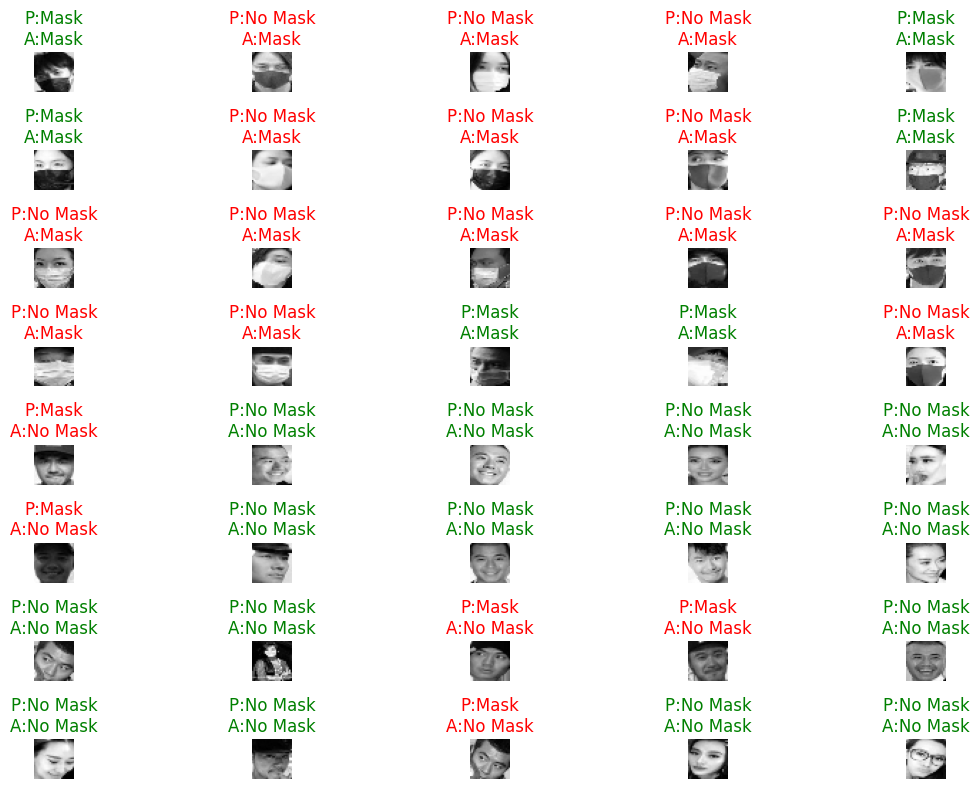

In [ ]:
class_names = ["Mask", "No Mask"]

n = len(X)
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(12,8))

for i in range(n):

    pred = predict_image(X[i])
    actual = y[i]

    plt.subplot(rows, cols, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.axis("off")

    color = "green" if pred == actual else "red"

    plt.title(f"P:{class_names[pred]}\nA:{class_names[actual]}", color=color)

plt.tight_layout()
plt.show()



## For multiclass from scratch,multiclass ,Mnist dataset,use 5 layers,hyperparameter, epochs atleast 50